In [1]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x1,x2 = sympy.symbols('x1 x2')

In [3]:
f_x = x1 - x2
f_x

x1 - x2

In [4]:
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
grad_f

[1, -1]

In [6]:
f_x_fcn = sympy.lambdify([x1,x2],f_x)

In [7]:
grad_fcn = sympy.lambdify([x1,x2],grad_f)

In [8]:
xx1,xx2 = np.meshgrid(np.linspace(-4,4,41),np.linspace(-4,4,41))

In [11]:
xx1_,xx2_ = np.meshgrid(np.linspace(-4,4,10),np.linspace(-4,4,10))
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1])

In [12]:
ff_x = f_x_fcn(xx1,xx2)

In [13]:
color_array = np.sqrt(V[0]**2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0]**2 + V[1] ** 2 + V_z**2)

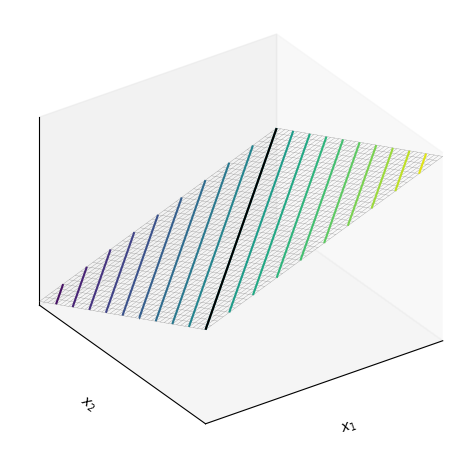

In [21]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,
                  cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20)
ax.contour3D(xx1,xx2,ff_x,levels = 0,colors = 'k')

# 设置坐标轴参数
ax.xaxis.set_ticks([])  # 去除 x 轴刻度
ax.yaxis.set_ticks([])  # 去除 y 轴刻度
ax.zaxis.set_ticks([])  # 去除 z 轴刻度
plt.xlim(-4, 4)  # 设置 x 轴范围
plt.ylim(-4, 4)  # 设置 y 轴范围
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
ax.set_proj_type('ortho')
plt.tight_layout()  # 调整布局以适应图形窗口

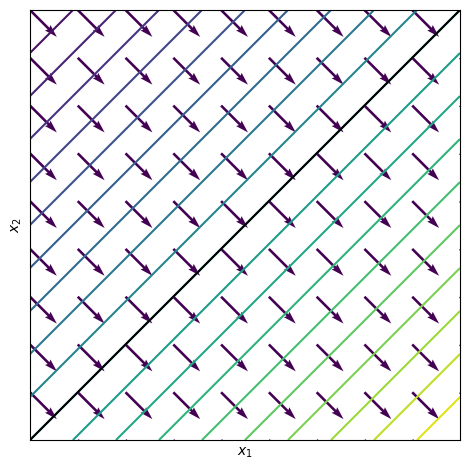

In [22]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,V[0],V[1],color_array,
           angles = 'xy',scale_units = 'xy',scale = 2,
           edgecolor = 'none',facecolor = 'b')

plt.contour(xx1,xx2,ff_x,20)
plt.contour(xx1,xx2,ff_x,levels = 0,colors = 'k')

ax.set_aspect('equal')  # 设置图形的纵横比
ax.xaxis.set_ticks([])  # 去除 x 轴刻度
ax.yaxis.set_ticks([])  # 去除 y 轴刻度
ax.set_xlabel(r'$x_1$')  # 设置 x 轴标签
ax.set_ylabel(r'$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局以适应图形窗口